# Chapter 267 - Multivariate Distributions

**Part VIII - Probability**

Single random variables are the building blocks. Machine learning deals with feature vectors, images, sequences: inherently multivariate objects. The multivariate normal is the workhorse, but its structure reveals principles that apply to any joint distribution.

## 1. Multivariate Normal - Setup and Sampling

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

rng = np.random.default_rng(42)

# Multivariate Normal: X ~ N(mu, Sigma)
# Key: covariance matrix Sigma must be positive semi-definite
mu = np.array([1.0, -0.5, 2.0])
Sigma = np.array([
    [2.0,  0.8, -0.3],
    [0.8,  1.5,  0.4],
    [-0.3, 0.4,  1.0]
])

samples = rng.multivariate_normal(mu, Sigma, 2000)
print(f"Shape: {samples.shape}")
print(f"Sample mean: {samples.mean(axis=0).round(3)}")
print(f"Sample cov:\n{np.cov(samples.T).round(3)}")


Shape: (2000, 3)
Sample mean: [ 0.959 -0.496  2.003]
Sample cov:
[[ 1.952  0.737 -0.262]
 [ 0.737  1.506  0.442]
 [-0.262  0.442  0.999]]


## 2. The Bivariate Case - Visualization

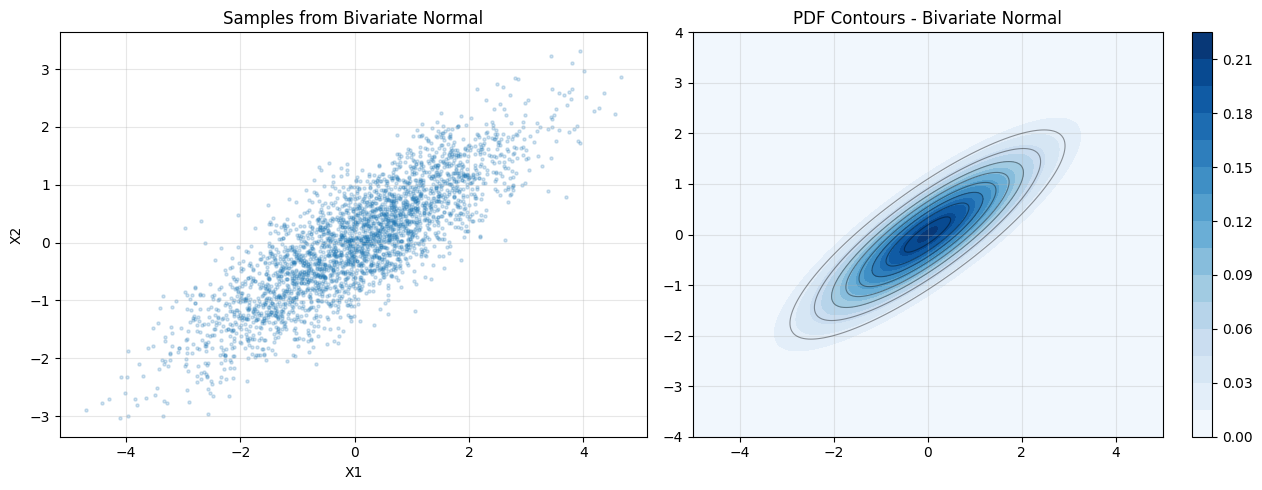

In [2]:
# 2D case for visualization
mu2 = np.array([0.0, 0.0])
Sigma2 = np.array([[2.0, 1.2], [1.2, 1.0]])
samples2 = rng.multivariate_normal(mu2, Sigma2, 3000)

x = np.linspace(-5, 5, 200)
y = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x, y)
pos = np.dstack([X, Y])
rv = multivariate_normal(mu2, Sigma2)
Z = rv.pdf(pos)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(samples2[:, 0], samples2[:, 1], alpha=0.2, s=5)
axes[0].set_title("Samples from Bivariate Normal")
axes[0].set_xlabel("X1"); axes[0].set_ylabel("X2")

cnt = axes[1].contourf(X, Y, Z, levels=20, cmap="Blues")
axes[1].contour(X, Y, Z, levels=8, colors="k", alpha=0.4, linewidths=0.8)
plt.colorbar(cnt, ax=axes[1])
axes[1].set_title("PDF Contours - Bivariate Normal")
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Conditional Distributions

A key property of the multivariate normal: all conditional and marginal distributions are themselves normal. The conditioning operation shifts the mean and reduces variance.

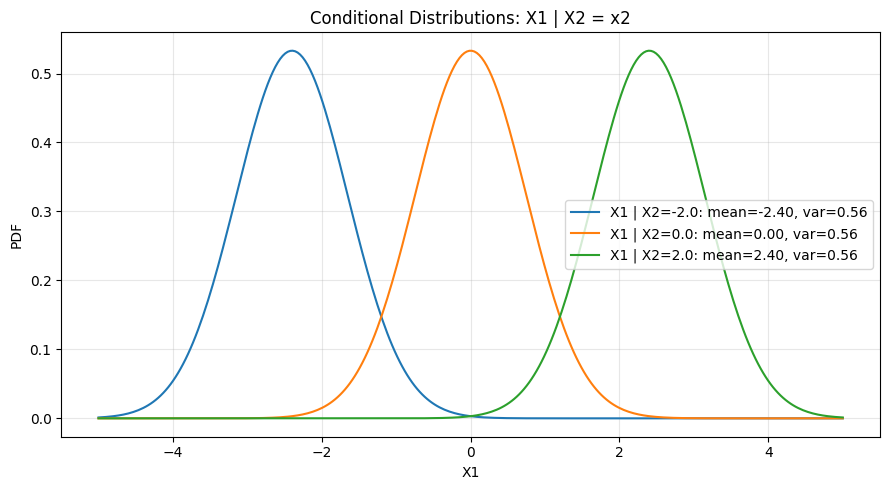

Marginal variance of X1: 2.0 (unchanged regardless of conditioning value)
Conditional variance: 0.5600 (always smaller than marginal)


In [3]:
# Marginals and conditionals of multivariate normal are themselves normal.
# If X = [X1, X2] with mean [mu1, mu2] and cov [[S11, S12], [S21, S22]]:
# Conditional: X1 | X2=x2 ~ N(mu1 + S12/S22*(x2-mu2), S11 - S12^2/S22)

mu1, mu2_s = 0.0, 0.0
S11, S12, S22 = 2.0, 1.2, 1.0
x2_vals = [-2.0, 0.0, 2.0]

x1_grid = np.linspace(-5, 5, 300)
fig, ax = plt.subplots(figsize=(9, 5))

from scipy.stats import norm
for x2v in x2_vals:
    cond_mean = mu1 + S12 / S22 * (x2v - mu2_s)
    cond_var  = S11 - S12**2 / S22
    cond_std  = np.sqrt(cond_var)
    ax.plot(x1_grid, norm.pdf(x1_grid, cond_mean, cond_std),
            label=f"X1 | X2={x2v:.1f}: mean={cond_mean:.2f}, var={cond_var:.2f}")

ax.set_xlabel("X1"); ax.set_ylabel("PDF")
ax.set_title("Conditional Distributions: X1 | X2 = x2")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Marginal variance of X1: {S11} (unchanged regardless of conditioning value)")
print(f"Conditional variance: {S11 - S12**2/S22:.4f} (always smaller than marginal)")


## 4. Mahalanobis Distance

The Mahalanobis distance accounts for correlation and scale. It is the natural distance metric in the space defined by the covariance structure. *(Sigma^{-1} introduced in ch157 - Matrix Inverse)*

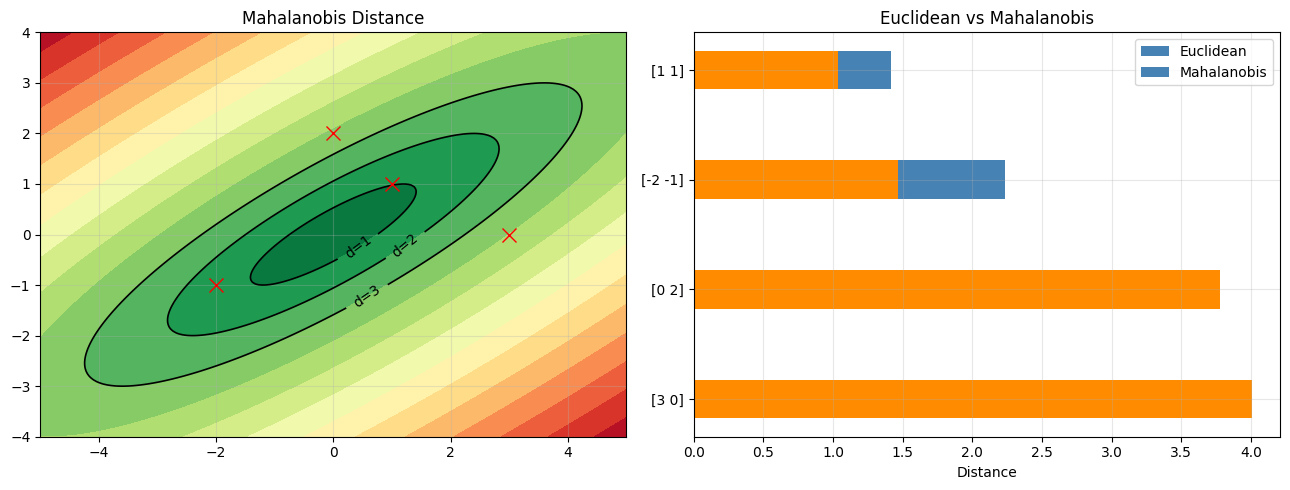

In [4]:
# Mahalanobis distance: generalization of z-score to multiple dimensions
# d^2(x, mu) = (x - mu)^T Sigma^{-1} (x - mu)
# Contours of constant Mahalanobis distance are ellipses aligned to Sigma.

Sigma_inv = np.linalg.inv(Sigma2)

def mahalanobis(x, mu, Sigma_inv):
    diff = x - mu
    return np.sqrt(diff @ Sigma_inv @ diff)

# Compute for grid
dists = np.array([[mahalanobis(np.array([xi, yi]), mu2, Sigma_inv)
                   for xi in x] for yi in y])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].contourf(X, Y, dists, levels=15, cmap="RdYlGn_r")
axes[0].set_title("Mahalanobis Distance")
c0 = axes[0].contour(X, Y, dists, levels=[1, 2, 3], colors="k", linewidths=1.2)
axes[0].clabel(c0, fmt="d=%.0f")

# Compare: Euclidean vs Mahalanobis for point classification
test_points = np.array([[3, 0], [0, 2], [-2, -1], [1, 1]])
for pt in test_points:
    mah = mahalanobis(pt.astype(float), mu2, Sigma_inv)
    euc = np.linalg.norm(pt - mu2)
    axes[0].plot(*pt, "rx", ms=10)
    axes[1].barh(str(pt), [euc, mah], 0.35,
                 color=["steelblue", "darkorange"])
axes[1].set_xlabel("Distance"); axes[1].set_title("Euclidean vs Mahalanobis")
axes[1].legend(["Euclidean", "Mahalanobis"])
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 5. Whitening Transform

Whitening maps any multivariate normal to N(0, I). This is foundational preprocessing: removes correlations and equalizes scales. *(Eigendecomposition from ch167 - Eigenvectors)*

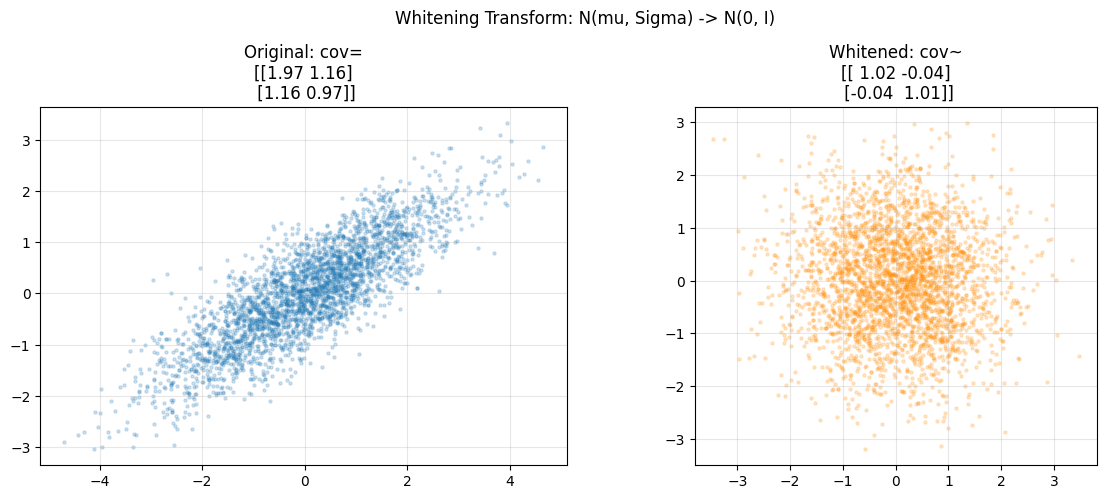

Whitening is used in PCA preprocessing (introduced in ch175 - PCA)
and in natural gradient methods in ML optimization.


In [5]:
# Whitening transform: decorrelate and standardize
# W = Sigma^{-1/2} maps N(mu, Sigma) to N(0, I)

eigenvalues, eigenvectors = np.linalg.eigh(Sigma2)
Sigma_sqrt_inv = eigenvectors @ np.diag(1.0 / np.sqrt(eigenvalues)) @ eigenvectors.T

whitened = (samples2 - mu2) @ Sigma_sqrt_inv.T

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(samples2[:, 0], samples2[:, 1], alpha=0.2, s=5)
axes[0].set_title(f"Original: cov=\n{np.cov(samples2.T).round(2)}")
axes[0].set_aspect("equal")
axes[1].scatter(whitened[:, 0], whitened[:, 1], alpha=0.2, s=5, color="darkorange")
axes[1].set_title(f"Whitened: cov~\n{np.cov(whitened.T).round(2)}")
axes[1].set_aspect("equal")
for ax in axes: ax.grid(alpha=0.3)
plt.suptitle("Whitening Transform: N(mu, Sigma) -> N(0, I)")
plt.tight_layout(); plt.show()

print("Whitening is used in PCA preprocessing (introduced in ch175 - PCA)")
print("and in natural gradient methods in ML optimization.")


## 6. Gaussian Processes - Infinite-Dimensional Extension

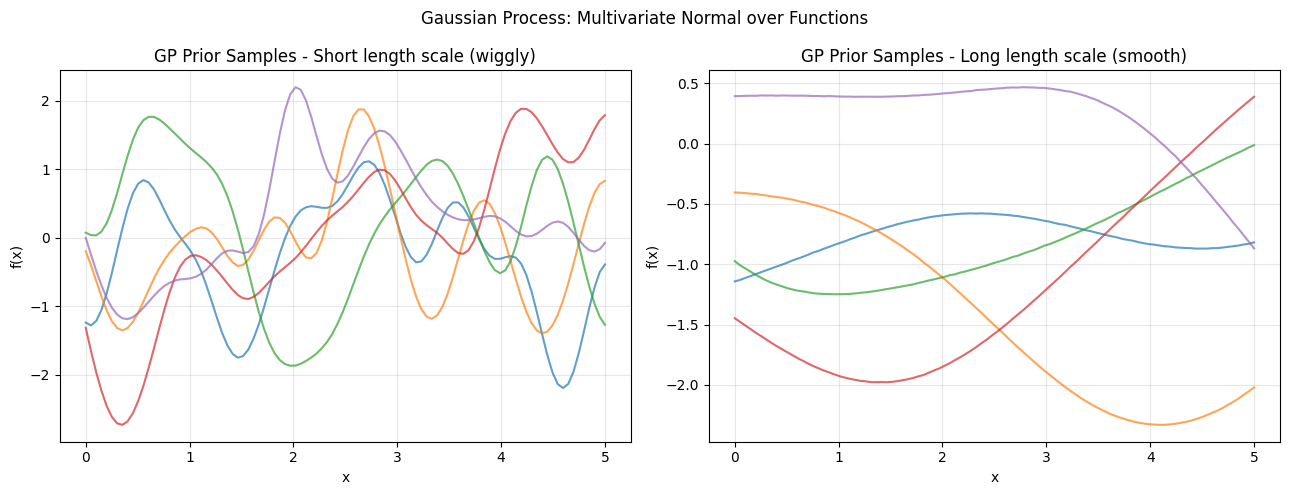

GPs provide a Bayesian non-parametric approach to function estimation.
Used in Bayesian optimization and spatial statistics (Kriging).


In [6]:
# Simulation: Gaussian process prior (1D, finite approximation)
# GP is an infinite-dimensional multivariate normal over functions.

def rbf_kernel(x1, x2, length_scale=1.0, amplitude=1.0):
    dist_sq = (x1[:, None] - x2[None, :]) ** 2
    return amplitude**2 * np.exp(-0.5 * dist_sq / length_scale**2)

x_grid = np.linspace(0, 5, 100)
n_samples_gp = 5

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, ls, title in zip(axes, [0.3, 2.0], ["Short length scale (wiggly)", "Long length scale (smooth)"]):
    K = rbf_kernel(x_grid, x_grid, length_scale=ls)
    K += 1e-6 * np.eye(len(x_grid))   # jitter for numerical stability
    gp_samples = rng.multivariate_normal(np.zeros(len(x_grid)), K, n_samples_gp)
    for s in gp_samples:
        ax.plot(x_grid, s, alpha=0.7)
    ax.set_title(f"GP Prior Samples - {title}")
    ax.set_xlabel("x"); ax.set_ylabel("f(x)"); ax.grid(alpha=0.3)
plt.suptitle("Gaussian Process: Multivariate Normal over Functions")
plt.tight_layout(); plt.show()
print("GPs provide a Bayesian non-parametric approach to function estimation.")
print("Used in Bayesian optimization and spatial statistics (Kriging).")


## 7. Summary

The multivariate normal is parameterized by mean vector mu and covariance matrix Sigma. Key operations:
- **Marginals**: project out dimensions
- **Conditionals**: slice with reduced variance
- **Mahalanobis**: distance respecting covariance
- **Whitening**: decorrelate to isotropic space

*(builds on ch247 - Random Variables, ch250 - Variance, ch175 - PCA)*

## 8. Forward References

- **ch277 - Correlation**: correlation as normalized covariance in data pipelines.
- **ch287 - Clustering**: Gaussian mixture models use multivariate normals per cluster.
- **ch295 - Neural Network Math Review**: weight initialization and batch normalization.